# 🏏 IPL Data Analysis (2008–2024)

## About This Project
This notebook presents a complete Exploratory Data Analysis (EDA) 
of Indian Premier League (IPL) matches from 2008 to 2024.

## Dataset
- **Source:** Kaggle
- **matches.csv** — 1095 matches across 17 seasons
- **deliveries.csv** — 260,920 ball by ball records

## Tools Used
Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn

## Topics Covered
- Team Performance | Toss Analysis | Season Trends
- Top Batsmen | Strike Rate | Top Bowlers | Economy Rate
- Match Win Prediction (ML Model)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import sklearn


In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [3]:
print("Matches shape:", matches.shape)
print("\nFirst 5 rows:")
matches.head()

Matches shape: (1095, 20)

First 5 rows:


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
print("Deliveries shape:", deliveries.shape)
print("\nFirst 5 rows:")
deliveries.head()

Deliveries shape: (260920, 17)

First 5 rows:


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [5]:
print("Null values in matches:")
print(matches.isnull().sum())

Null values in matches:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [6]:
print("Total matches:", matches.shape[0])
print("Total columns:", matches.shape[1])
print("\nSeasons covered:", matches['season'].unique())
print("\nTotal teams:", matches['team1'].nunique())

Total matches: 1095
Total columns: 20

Seasons covered: <StringArray>
['2007/08',    '2009', '2009/10',    '2011',    '2012',    '2013',    '2014',
    '2015',    '2016',    '2017',    '2018',    '2019', '2020/21',    '2021',
    '2022',    '2023',    '2024']
Length: 17, dtype: str

Total teams: 19


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


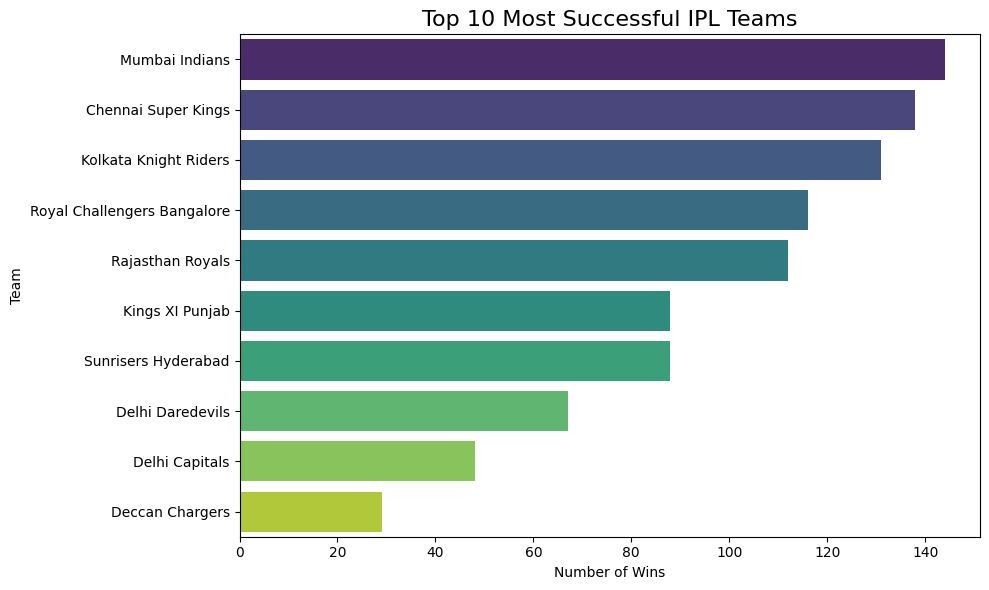

In [7]:
team_wins = matches['winner'].value_counts().head(10)
print(team_wins)
plt.figure(figsize=(10,6))
sns.barplot(x=team_wins.values, y=team_wins.index, hue=team_wins.index, legend=False, palette='viridis')
plt.title('Top 10 Most Successful IPL Teams', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

## Team Performance Analysis

- Mumbai Indians lead with 144 wins — most successful IPL team
- Chennai Super Kings (138) and Kolkata Knight Riders (131) 
  follow closely
- Top 3 teams have won 413 matches combined out of 1095 — 
  nearly 38% of all IPL matches!
- Gujarat Titans have 28 wins in just 3 seasons (2022–2024)

Team Who won the Toss & match: 554
Team Whon won the Toss but not match:541
Toss winners who won the match: 50.59 %
Toss winners who lost the match: 49.41%


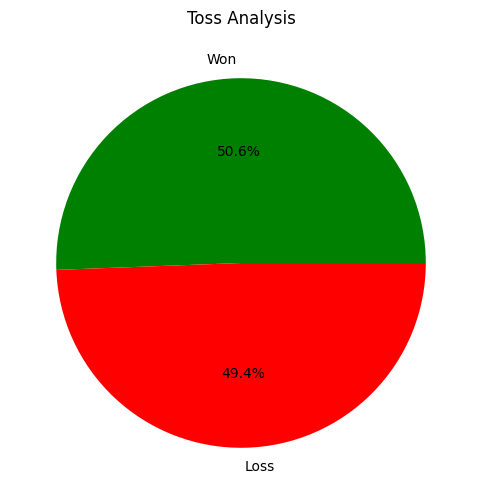

In [8]:
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']
is_winner=matches['toss_match_winner'].value_counts()
print(f"Team Who won the Toss & match: {is_winner[True]}")
print(f"Team Whon won the Toss but not match:{is_winner[False]}")
wins_percentage=is_winner/matches.shape[0]*100
print(f"Toss winners who won the match: {wins_percentage[True]:.2f} %")
print(f"Toss winners who lost the match: {wins_percentage[False]:.2f}%")

plt.figure(figsize=(6,6))
plt.pie(is_winner.values, labels=['Won', 'Loss'], autopct='%1.1f%%', colors=['green', 'red'])
plt.title("Toss Analysis")
plt.show()



season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: id, dtype: int64


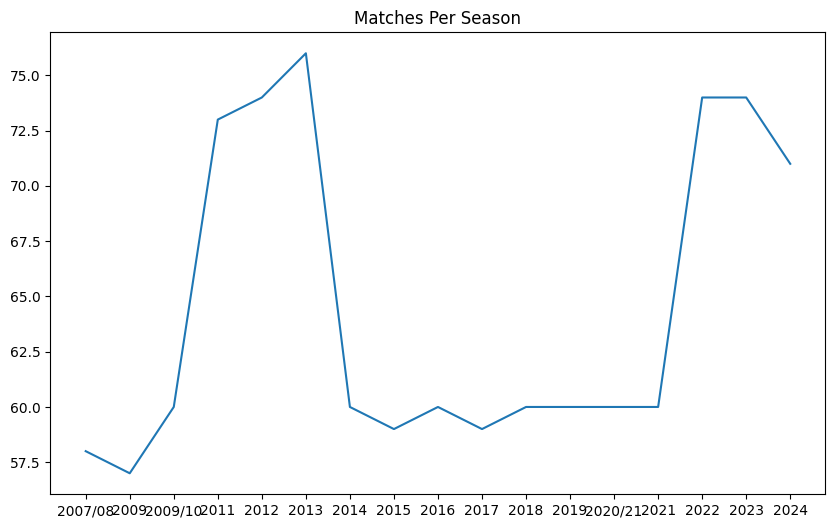

In [9]:
match_count=matches.groupby('season')['id'].count()
print(match_count)
plt.figure(figsize=(10,6))
x_labels=match_count.index
y_labels=match_count.values
plt.plot(x_labels,y_labels)
plt.title("Matches Per Season")
plt.show()



winner
Chennai Super Kings            138
Deccan Chargers                 29
Delhi Capitals                  48
Delhi Daredevils                67
Gujarat Lions                   13
Gujarat Titans                  28
Kings XI Punjab                 88
Kochi Tuskers Kerala             6
Kolkata Knight Riders          131
Lucknow Super Giants            24
Mumbai Indians                 144
Pune Warriors                   12
Punjab Kings                    24
Rajasthan Royals               112
Rising Pune Supergiant          10
Rising Pune Supergiants          5
Royal Challengers Bangalore    116
Royal Challengers Bengaluru      7
Sunrisers Hyderabad             88
Name: season, dtype: int64
toss_decision
field    704
bat      391
Name: count, dtype: int64


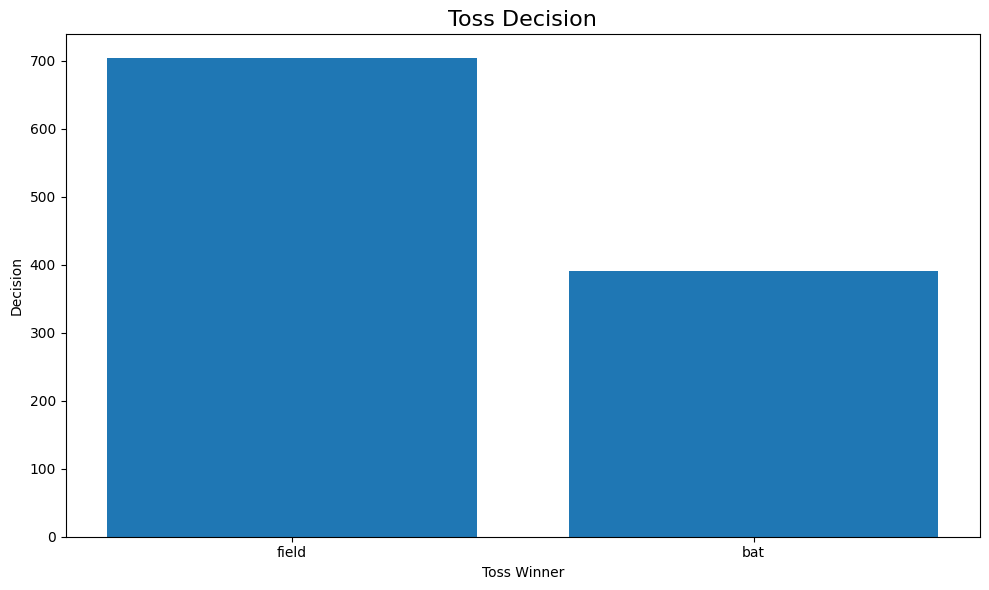

In [10]:
win_count=matches.groupby('winner')['season'].count()
print(win_count)
decision_by_toss=matches['toss_decision'].value_counts()
print(decision_by_toss)
plt.figure(figsize=(10,6))
x_labels=decision_by_toss.index
y_labels=decision_by_toss.values
plt.bar(x_labels,y_labels)
plt.title('Toss Decision', fontsize=16)
plt.xlabel('Toss Winner')
plt.ylabel('Decision')
plt.tight_layout()
plt.show()


## Season wise Trends

- 2013 was the peak season with 76 matches
- 2014-2021 stabilized around 60 matches per season
- 2022 jumped back to 74 with Gujarat Titans 
  and Lucknow Super Giants joining
- 70% of captains prefer fielding first after winning toss

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


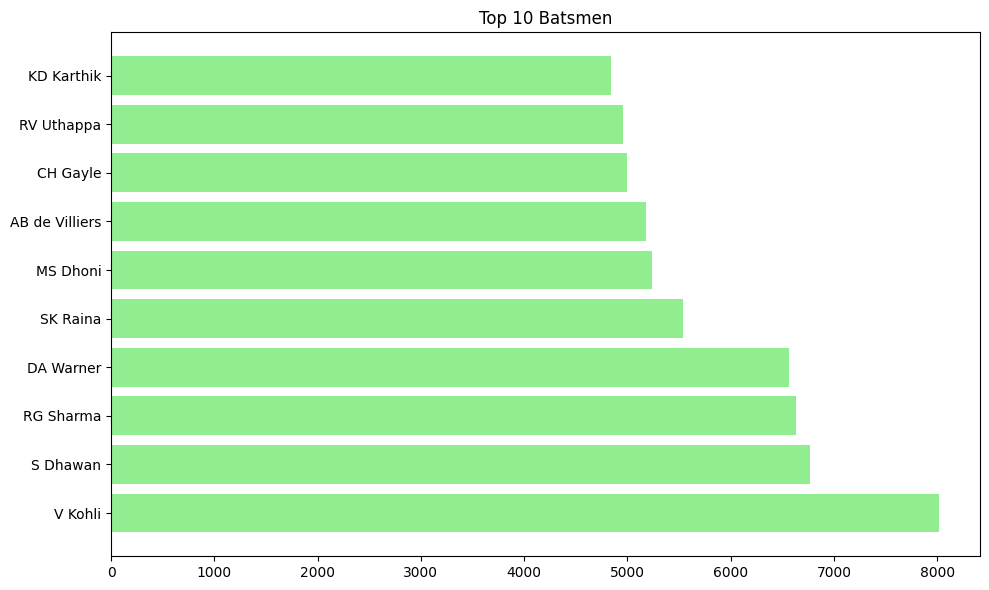

In [11]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print(top_batsmen)
plt.figure(figsize=(10,6))
x_labels=top_batsmen.index
y_labels=top_batsmen.values
plt.barh(x_labels,y_labels,color='lightgreen')
plt.title("Top 10 Batsmen")
plt.tight_layout()
plt.show()

In [12]:
runs = deliveries.groupby('batter')['batsman_runs'].sum()
balls = deliveries.groupby('batter')['batsman_runs'].count()
strike_rate = (runs/balls*100)
strike_rate = strike_rate[balls >=200].sort_values(ascending=False).head(10)
print(strike_rate.round(2))

batter
PD Salt           169.61
T Stubbs          169.46
TM Head           168.56
AD Russell        164.22
H Klaasen         161.99
TH David          158.03
SP Narine         155.89
Shashank Singh    155.51
N Pooran          154.77
LS Livingstone    154.19
Name: batsman_runs, dtype: float64


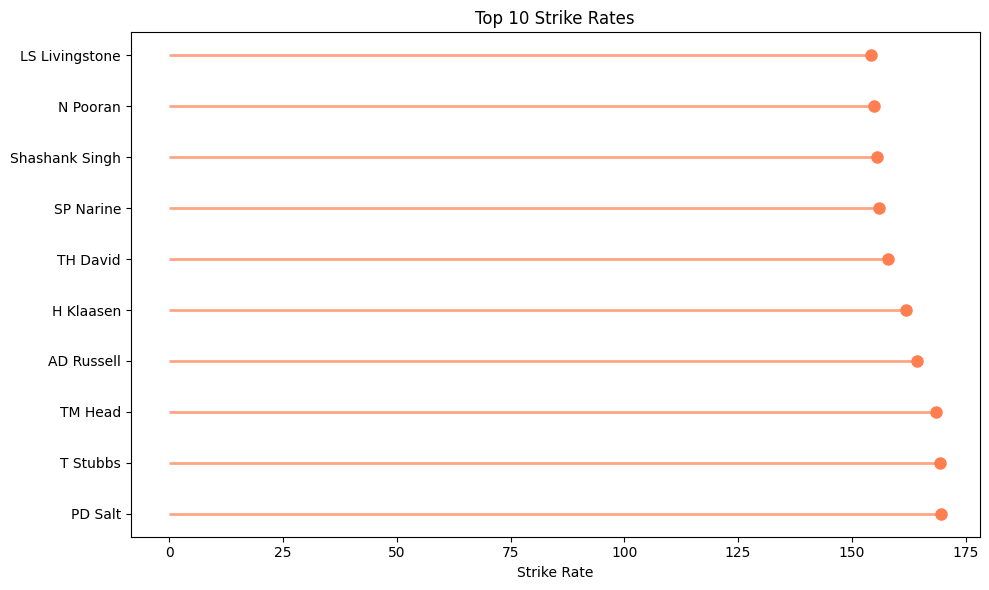

In [13]:
plt.figure(figsize=(10,6))
plt.hlines(y=strike_rate.index, xmin=0, xmax=strike_rate.values, color='coral', alpha=0.7, linewidth=2)
plt.plot(strike_rate.values, strike_rate.index, 'o', color='coral', markersize=8)
plt.title('Top 10 Strike Rates')
plt.xlabel('Strike Rate')
plt.tight_layout()
plt.show()

In [14]:
boundaries = deliveries[deliveries['batsman_runs'].isin([4,6])]
top_boundaries = boundaries.groupby('batter')['batsman_runs'].count().sort_values(ascending=False).head(10)
print(top_boundaries)

batter
V Kohli           981
S Dhawan          921
DA Warner         899
RG Sharma         880
CH Gayle          767
SK Raina          710
AB de Villiers    667
RV Uthappa        663
KD Karthik        627
MS Dhoni          615
Name: batsman_runs, dtype: int64


## Batting Analysis

### Top Run Scorers
- Virat Kohli leads with 8014 runs — undisputed IPL batting king
- Top 3 are Kohli, Dhawan and Rohit Sharma — all Indian players
- Top 10 includes 8 Indians and 2 overseas (Chris Gayle, AB de Villiers)
  both remarkably from Royal Challengers Bangalore

### Boundaries
- Kohli leads boundaries too with 981 fours and sixes
- Same players dominate both runs and boundaries

### Strike Rate
- Top 10 strike rates dominated by overseas players
- Only **Shashank Singh** represents India in top 10
- PD Salt leads with 169.61 strike rate
- Overseas players are selected specifically for explosive batting
  — explains their higher strike rates

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64


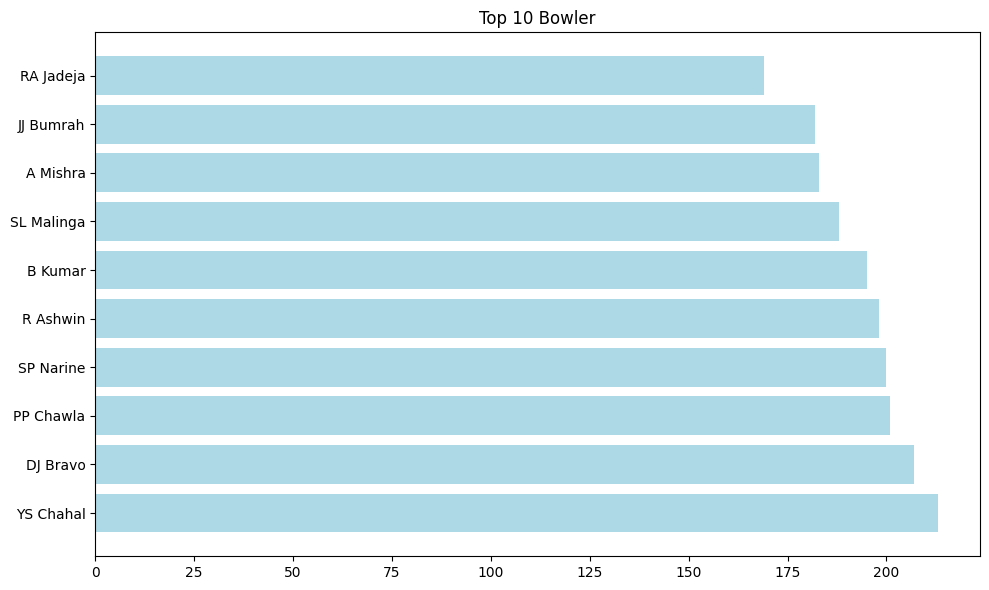

In [15]:
wickets = deliveries[deliveries['is_wicket'].isin([1])]
top_wickets = wickets.groupby('bowler')['is_wicket'].count().sort_values(ascending=False).head(10)
print(top_wickets)
plt.figure(figsize=(10,6))
x_labels=top_wickets.index
y_labels=top_wickets.values
plt.barh(x_labels,y_labels,color='lightblue')
plt.title("Top 10 Bowler")
plt.tight_layout()
plt.show()

In [16]:
total_runs_given = deliveries.groupby('bowler')['total_runs'].sum()
overs_bowled = deliveries.groupby('bowler')['ball'].count() / 6
economy = (total_runs_given / overs_bowled)
economy = economy[overs_bowled >=30].sort_values().head(10)
print(economy.round(2))

bowler
Sohail Tanvir      6.23
A Chandila         6.28
SMSM Senanayake    6.49
SM Pollock         6.58
A Kumble           6.65
GD McGrath         6.67
M Muralitharan     6.70
IS Sodhi           6.73
J Yadav            6.74
SP Narine          6.76
dtype: float64


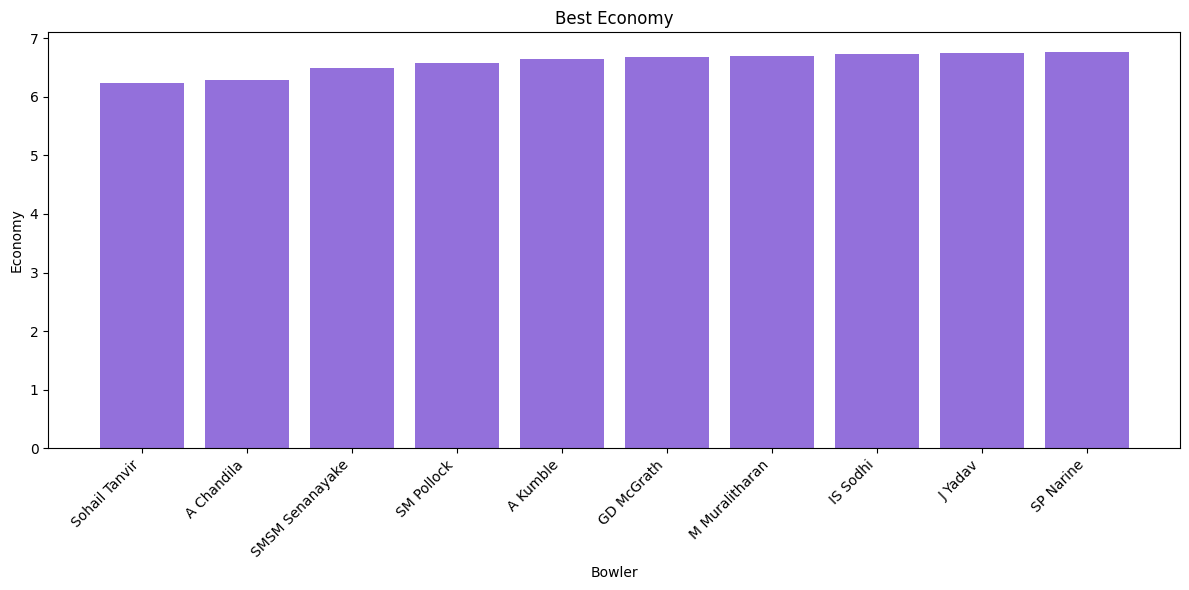

In [17]:
x_labels=economy.index
y_labels=economy.values
plt.figure(figsize=(12,6))
plt.bar(x_labels, y_labels, color='mediumpurple')
plt.title('Best Economy')
plt.xlabel('Bowler')
plt.ylabel('Economy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Top Bowlers Analysis

### Wicket Takers
- Yuzvendra Chahal has Dominated the Wicket Takers with 213 wickets till 2024.
- The Top 10 list conclude 8 spinners while only 2 pace Bowlers(Bumrah and Malinga)

### Economy Rate  
- The legendary glory is shinning bright in Economy rates
- Sohail Tanvir with the best economy rate 

### Key Finding
- Sunil Narine The Only Bowler Dominating with Taking wickets with best Economy Rate
- Sunil Narine — 200 wickets AND 6.76 economy rate — only bowler in top 10 of both categories

## Statistical Summary

In [18]:
print("=== MATCH STATISTICS ===")
print(f"Total Matches: {matches.shape[0]}")
print(f"Total Seasons: {matches['season'].nunique()}")
print(f"Total Teams: {matches['team1'].nunique()}")
print(f"Average matches per season: {matches.shape[0]/matches['season'].nunique():.2f}")
print("\n=== BATTING STATISTICS ===")
print(f"Average runs per batter: {runs.mean():.2f}")
print(f"Highest individual total: {runs.max()} by {runs.idxmax()}")
print("\n=== BOWLING STATISTICS ===")
print(f"Average wickets per bowler: {wickets.groupby('bowler')['is_wicket'].count().mean():.2f}")
print(f"Most wickets: {top_wickets.max()} by {top_wickets.idxmax()}")


=== MATCH STATISTICS ===
Total Matches: 1095
Total Seasons: 17
Total Teams: 19
Average matches per season: 64.41

=== BATTING STATISTICS ===
Average runs per batter: 490.44
Highest individual total: 8014 by V Kohli

=== BOWLING STATISTICS ===
Average wickets per bowler: 28.46
Most wickets: 213 by YS Chahal


## Why ML Model?
IPL match prediction is a real world analytics problem.
This model attempts to predict match winners based on 
pre-match information — toss result, venue and teams.
While perfect prediction is impossible in cricket,
this demonstrates how machine learning can find 
patterns in historical sports data.

## Match Win Prediction (ML Model)

Using Logistic Regression to predict match winner
based on toss result, venue and teams.


In [20]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [21]:
ml_data = matches[['toss_winner','toss_decision','team1','team2','venue','winner']].dropna()
print(ml_data.shape)

(1090, 6)


In [22]:
le = LabelEncoder()

ml_data['toss_winner'] = le.fit_transform(ml_data['toss_winner'])
ml_data['toss_decision'] = le.fit_transform(ml_data['toss_decision'])
ml_data['team1'] = le.fit_transform(ml_data['team1'])
ml_data['team2'] = le.fit_transform(ml_data['team2'])
ml_data['venue'] = le.fit_transform(ml_data['venue'])
ml_data['winner'] = le.fit_transform(ml_data['winner'])

print(ml_data.head())

   toss_winner  toss_decision  team1  team2  venue  winner
0           16              1     16      8     23       8
1            0              0      6      0     40       0
2           13              0      3     13     16       3
3           10              0     10     16     55      16
4            1              0      8      1     14       8


In [23]:
X = ml_data.drop('winner', axis=1)
y = ml_data['winner']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1090, 5)
Target shape: (1090,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (872, 5)
Testing size: (218, 5)


In [25]:
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [26]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

Model Accuracy: 24.77%


In [27]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.39      0.59      0.47        37
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        13
           4       0.00      0.00      0.00         5
           5       0.00      0.00      0.00         9
           6       0.00      0.00      0.00        17
           7       0.00      0.00      0.00         2
           8       0.20      0.39      0.27        23
           9       0.00      0.00      0.00         3
          10       0.15      0.31      0.20        26
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         3
          13       0.29      0.08      0.12        25
          14       0.00      0.00      0.00         4
          16       0.30      0.27      0.29        26
          17       0.00      0.00      0.00         2
          18       0.21    

## Key Insights

- This notebook presents IPL insights from 2008–2024 covering 
  1095 matches across 17 seasons and 19 teams.

- **Mumbai Indians** dominate as the most successful team 
  with 144 wins overall.

- **Virat Kohli** holds the crown of most runs (8014) and 
  most boundaries (981). **Yuzvendra Chahal** leads wicket 
  takers with 213 wickets. Best economy goes to **Sohail Tanvir** 
  at 6.23 runs per over.

- Top 10 batsmen include 8 Indian players and 2 overseas — 
  **Chris Gayle** and **AB de Villiers** — both remarkably 
  from Royal Challengers Bangalore. Same pattern reflects 
  in boundary hitters.

- Spinners dominated the bowling attack in top 10 wicket 
  takers. Only 2 pace bowlers made it — **Bumrah and Malinga** 
  — both from Mumbai Indians.

- Strike rate analysis reveals an interesting pattern — 
  top 10 strike rates are dominated by overseas players 
  with only **Shashank Singh** representing India. 
  Overseas slots are reserved for explosive batsmen 
  while Indian players focus on accumulation and consistency.

- Economy rates tell a legendary story. Historical greats like 
  **Tanvir, Muralitharan and McGrath** top the economy charts 
  — proof that classical bowling arts were more economical.

- **Sunil Narine** is the only active bowler dominating both 
  wickets (200) and economy (6.76) simultaneously.

- ML model accuracy is 24.77%. IPL has 19 teams with some 
  dominating for years while others lasted only 1–2 seasons 
  — causing class imbalance in predictions.

- *"At the end, cricket is an unpredictable game. It starts from the silence of a toss and ends with a nail biting single ,six ,dot or a wicket. Enjoying it without having a heart attack is itself an ART!" 🏏❤️*

## SQL Analysis Using SQLite
In this section, we query the IPL dataset using SQL to extract structured insights.


In [22]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect('ipl.db')

# Load existing dataframes into SQL tables
matches.to_sql('matches', conn, if_exists='replace', index=False)
deliveries.to_sql('deliveries', conn, if_exists='replace', index=False)

print("✅ Database created successfully!")
print(f"Matches table: {len(matches)} rows")
print(f"Deliveries table: {len(deliveries)} rows")

✅ Database created successfully!
Matches table: 1095 rows
Deliveries table: 260920 rows


### Query 1: Most Wins by Team (All Time)

In [23]:
query1 = """
SELECT winner, COUNT(*) as total_wins
FROM matches
WHERE winner != ''
GROUP BY winner
ORDER BY total_wins DESC
LIMIT 10;
"""

result1 = pd.read_sql_query(query1, conn)
print(result1)

                        winner  total_wins
0               Mumbai Indians         144
1          Chennai Super Kings         138
2        Kolkata Knight Riders         131
3  Royal Challengers Bangalore         116
4             Rajasthan Royals         112
5          Sunrisers Hyderabad          88
6              Kings XI Punjab          88
7             Delhi Daredevils          67
8               Delhi Capitals          48
9              Deccan Chargers          29


### Query 2: Which team won the most matches batting first?

In [24]:
query2="""
SELECT winner,COUNT(winner) as wins
FROM matches
WHERE toss_decision='bat' AND toss_winner=winner
GROUP BY winner
ORDER BY wins DESC
LIMIT 10 ;
"""

result2=pd.read_sql_query(query2,conn)
print(result2)


                        winner  wins
0          Chennai Super Kings    35
1               Mumbai Indians    30
2        Kolkata Knight Riders    20
3             Rajasthan Royals    18
4  Royal Challengers Bangalore    16
5          Sunrisers Hyderabad    12
6             Delhi Daredevils    11
7              Deccan Chargers    11
8               Delhi Capitals     7
9              Kings XI Punjab     6


### Query 3: Top 5 venues with most matches played?

In [25]:
query3="""
SELECT venue , COUNT(venue) as most_played
FROM matches
GROUP BY venue
ORDER BY most_played DESC
LIMIT 10;
"""
result3=pd.read_sql_query(query3,conn)
print(result3)

                                        venue  most_played
0                                Eden Gardens           77
1                            Wankhede Stadium           73
2                       M Chinnaswamy Stadium           65
3                            Feroz Shah Kotla           60
4   Rajiv Gandhi International Stadium, Uppal           49
5             MA Chidambaram Stadium, Chepauk           48
6                      Sawai Mansingh Stadium           47
7         Dubai International Cricket Stadium           46
8                    Wankhede Stadium, Mumbai           45
9  Punjab Cricket Association Stadium, Mohali           35


### Query 4: Which season had the highest average score?

In [26]:
query4="""
SELECT season , AVG(target_runs) as high_avg
FROM matches
GROUP BY season
ORDER BY high_avg DESC
LIMIT 10;
"""

result4=pd.read_sql_query(query4,conn)
print(result4)

    season    high_avg
0     2024  190.591549
1     2023  183.397260
2     2022  172.121622
3  2020/21  170.500000
4     2018  170.200000
5     2019  167.733333
6  2009/10  165.783333
7     2017  165.406780
8     2015  164.706897
9     2014  162.383333


### Query 5: Top 10 run scorers using deliveries table

In [27]:
query5="""
SELECT batter, SUM(batsman_runs) as high_score
FROM deliveries
GROUP BY batter
ORDER BY high_score DESC
LIMIT 10;
"""

result5=pd.read_sql_query(query5,conn)
print(result5)

           batter  high_score
0         V Kohli        8014
1        S Dhawan        6769
2       RG Sharma        6630
3       DA Warner        6567
4        SK Raina        5536
5        MS Dhoni        5243
6  AB de Villiers        5181
7        CH Gayle        4997
8      RV Uthappa        4954
9      KD Karthik        4843


### Query 6: Top 10 wicket takers using deliveries table

In [28]:
query6="""
SELECT bowler, COUNT(player_dismissed) as high_wicket
FROM deliveries
GROUP BY bowler
ORDER BY high_wicket DESC
LIMIT 10;
"""
result6=pd.read_sql_query(query6,conn)
print(result6)


       bowler  high_wicket
0   YS Chahal          213
1    DJ Bravo          207
2   PP Chawla          201
3   SP Narine          200
4    R Ashwin          198
5     B Kumar          195
6  SL Malinga          188
7    A Mishra          183
8   JJ Bumrah          182
9   RA Jadeja          169


In [20]:
print("MATCHES columns:")
print(matches.columns.tolist())

print("\nDELIVERIES columns:")
print(deliveries.columns.tolist())

MATCHES columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2', 'toss_match_winner']

DELIVERIES columns:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


### Query 7: Find the total runs scored by each batting team, but only for matches played at 'Eden Gardens'.

In [31]:
query7="""
SELECT match_id,batting_team,SUM(total_runs)
FROM matches 
JOIN deliveries ON matches.id=deliveries.match_id
WHERE venue='Eden Gardens'
GROUP BY match_id,batting_team
ORDER BY SUM(total_runs) DESC
LIMIT 10;
"""
result7=pd.read_sql_query(query7,conn)
print(result7)

   match_id                 batting_team  SUM(total_runs)
0   1178422        Kolkata Knight Riders              232
1   1175361        Kolkata Knight Riders              218
2   1178410  Royal Challengers Bangalore              213
3   1136601               Mumbai Indians              210
4    419139              Kings XI Punjab              204
5   1178410        Kolkata Knight Riders              203
6    829823               Mumbai Indians              202
7    419139        Kolkata Knight Riders              200
8   1136573        Kolkata Knight Riders              200
9   1178422               Mumbai Indians              198


### Query 8: Show the top 10 batters along with the name of the venue where they scored their highest total in a single match.

In [37]:
 #batter name, venue, runs scored
query8="""
SELECT batter, venue, SUM(batsman_runs) as total_runs
FROM deliveries
JOIN matches ON deliveries.match_id = matches.id
GROUP BY batter, venue
ORDER BY total_runs DESC
LIMIT 10;
"""
result8=pd.read_sql_query(query8,conn)
print(result8)

           batter                                      venue  total_runs
0         V Kohli                      M Chinnaswamy Stadium        1874
1       RG Sharma                           Wankhede Stadium        1733
2        CH Gayle                      M Chinnaswamy Stadium        1534
3       G Gambhir                               Eden Gardens        1407
4  AB de Villiers                      M Chinnaswamy Stadium        1401
5        SK Raina            MA Chidambaram Stadium, Chepauk        1302
6      KA Pollard                           Wankhede Stadium        1209
7       DA Warner  Rajiv Gandhi International Stadium, Uppal        1169
8      RV Uthappa                               Eden Gardens        1159
9        MS Dhoni            MA Chidambaram Stadium, Chepauk        1145


In [38]:
conn.close()
print("✅ Database connection closed.")

✅ Database connection closed.


## SQL Key Insights

- **Mumbai Indians** dominate overall with most wins, but **Chennai Super Kings** are the best "bat first and win" team with 35 wins
- **Eden Gardens** is the most used IPL venue with 77 matches
- IPL scoring has increased significantly — 2024 had the highest average target of 190+ runs
- **Virat Kohli** leads all-time run scoring with 8,014 runs
- **YS Chahal** is the highest wicket taker with 213 wickets
- **Kolkata Knight Riders** dominate their home ground, posting the highest single-innings totals at Eden Gardens (232, 218, 203 runs) — home advantage clearly reflected in the data
- Batter-venue analysis reveals strong "home ground" patterns — **Virat Kohli** (1,874 runs at M. Chinnaswamy Stadium), **Rohit Sharma** (1,733 runs at Wankhede), and **MS Dhoni/Suresh Raina** (1,145/1,302 runs at MA Chidambaram Stadium) all rack up their highest totals at their own team's home venue
- Data quality issue found: Wankhede Stadium appears under two different names in the dataset